# Agricultural Question Answering with a Fine-Tuned Small Language Model
### TinyLlama-1.1B + QLoRA — Notebook A: Environment, Training & Evaluation

---


> **This is Notebook A of two.** It handles environment setup, data, training, evaluation,
> and computational-efficiency benchmarking, and ends by saving the trained adapter to Google
> Drive. **Notebook B (`NotebookB_Reload_and_QA.ipynb`)** is a separate file that starts a
> fresh session and loads the model produced here — with no training code at all — to prove
> the trained model persists across sessions and can be reused without retraining.


## Research Gap, Objectives, and Contribution

**Gap.** Large Language Models can answer open-domain agricultural questions well but are
too resource-heavy to fine-tune or deploy on modest hardware. Small Language Models (SMLs,
under ~2B parameters) are cheap enough to adapt and deploy, but their out-of-the-box
(zero-shot) performance on a specialised domain like agriculture is largely unmeasured, and it
is unclear whether parameter-efficient fine-tuning (LoRA/QLoRA) closes that gap **without**
losing the resource efficiency that makes SMLs attractive in the first place.

**Research Objectives**

| # | Objective |
|---|---|
| O1 | Measure, on identical data and metrics, how much a QLoRA fine-tuned SML improves over its own zero-shot (base) performance on agricultural QA. |
| O2 | Provide objective, controlled computational-efficiency evidence (parameters, training cost, inference latency/throughput/memory) for the fine-tuned system against the base-model baseline. |
| O3 | Build a question-answering interface that accepts a plain question (no user-supplied context), and communicates a confidence level with each answer, including for out-of-domain or unsupported questions. |
| O4 | Demonstrate the trained model persists across sessions: save once, reload later with no retraining, and reproduce the same answers. |
| O5 | Critically analyse the results against O1-O4, not just report numbers. |

**Research contribution.** The contribution of this work is **not** "fine-tuning TinyLlama" in
isolation — that step alone is a standard application of an existing method (QLoRA) to an
existing model. The contribution is the combination of:

1. A **controlled base-vs-fine-tuned evaluation protocol**: the same test set, the same
   prompt template, and the same metric implementations are used for both the base SML and
   the fine-tuned SML (Parts 7, 10, 11), so any measured difference is attributable to the
   fine-tuning step itself rather than to differences in how each was evaluated.
2. A **quantitative computational-efficiency benchmark** that treats efficiency as an
   experiment with a defined baseline, multiple trials, and reported variance rather than a
   qualitative claim (Part 12).
3. A **confidence-estimation and out-of-domain-detection layer** on top of generation, so the
   system's output includes an explicit, explained reliability signal instead of presenting
   every answer as equally trustworthy (Part 6, Part 14).
4. A **validated persistence workflow** proving the small (megabyte-scale) LoRA adapter can be
   saved, the session torn down, and the exact same behaviour reproduced from disk alone
   (Part 13).

Part 15 maps each objective explicitly back to the section that produces evidence for it.


## Implementation Roadmap

| Part | Purpose | Key Output |
|---|---|---|
| 1 | Environment setup | Reproducible environment, seeded |
| 2 | Dataset acquisition & preprocessing | Cleaned, deduplicated train/val/test CSVs |
| 3 | Exploratory data analysis | Distribution plots, summary stats |
| 4 | Technical background | TinyLlama / LoRA / QLoRA mechanisms explained |
| 5 | Base model loading | Quantised base SML, unmodified |
| 6 | Core Q&A & evaluation utilities | **Single** canonical prompt/generate/evaluate/confidence implementation, reused by every later part |
| 7 | Baseline evaluation | Zero-shot BLEU/ROUGE/BERTScore (the "before") |
| 8 | LoRA/QLoRA configuration | Trainable adapter attached, parameter-efficiency stats |
| 9 | Fine-tuning | Trained adapter, training time/memory captured |
| 10 | Fine-tuned evaluation | Same metrics, same test set (the "after") |
| 11 | Baseline vs. fine-tuned comparison | Side-by-side table, chart, critical analysis |
| 12 | Computational efficiency experiment | Multi-trial latency/throughput/memory, base vs. fine-tuned |
| 13 | Persistence validation | Fresh-session reload, reproduced output |
| 14 | Interactive Q&A | Question-only input, confidence shown |
| 15 | Conclusion | Objectives-to-evidence map, limitations |

---


# Part 1: Environment Setup


In [1]:
!pip install -q --no-warn-conflicts \
transformers==4.56.2 \
datasets==4.0.0 \
peft==0.17.1 \
trl==0.21.0 \
accelerate==1.10.1 \
bitsandbytes==0.47.0 \
torchvision==0.23.0 \
sentencepiece \
evaluate \
rouge_score \
bert-score

import transformers
import huggingface_hub
import datasets
import peft
import accelerate
import trl
import torch

print("="*60)
print("Environment Summary")
print("="*60)
print("Transformers :", transformers.__version__)
print("Hub          :", huggingface_hub.__version__)
print("Datasets     :", datasets.__version__)
print("PEFT         :", peft.__version__)
print("TRL          :", trl.__version__)
print("Accelerate   :", accelerate.__version__)
print("Torch        :", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("GPU Count :", torch.cuda.device_count())
else:
    print("No GPU Detected. Please enable GPU from:")
    print("Runtime -> Change runtime type -> T4 GPU")

import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
import evaluate

warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   

In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print("Random Seed =", seed)

from google.colab import drive
drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/Agriculture_QA"

folders = ["dataset", "models", "results", "plots", "checkpoints"]
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)
print("Project folders created successfully.")

Random Seed = 42
Mounted at /content/drive
Project folders created successfully.


# Part 2: Dataset Acquisition & Preprocessing


In [5]:
dataset = load_dataset("msu-ceco/agxqa_v1")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

agxqa-train-2024-06-11.jsonl: 0.00B [00:00, ?B/s]

agxqa-validation-2024-06-11.jsonl: 0.00B [00:00, ?B/s]

agxqa-test-2024-06-11.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1503 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/353 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/330 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'context', 'question', 'answers', 'references'],
        num_rows: 1503
    })
    validation: Dataset({
        features: ['id', 'category', 'context', 'question', 'answers', 'references'],
        num_rows: 353
    })
    test: Dataset({
        features: ['id', 'category', 'context', 'question', 'answers', 'references'],
        num_rows: 330
    })
})


In [6]:
print("="*60)
print("Training Samples    :", len(dataset["train"]))
print("Validation Samples  :", len(dataset["validation"]))
print("Testing Samples     :", len(dataset["test"]))
print("="*60)

print(dataset["train"].features)

Training Samples    : 1503
Validation Samples  : 353
Testing Samples     : 330
{'id': Value('string'), 'category': Value('string'), 'context': Value('string'), 'question': Value('string'), 'answers': {'text': List(Value('string')), 'answer_start': List(Value('int32'))}, 'references': Value('string')}


In [7]:
for i in random.sample(range(len(dataset["train"])), 5):
    print("="*80)
    print("Question:\n")
    print(dataset["train"][i]["question"])
    print("\nContext:\n")
    print(dataset["train"][i]["context"][:400])
    print("\nAnswer:\n")
    print(dataset["train"][i]["answers"])
    print("="*80)

Question:

why should an irrigator not over oil a pump?

Context:

 2) Pump - The pump is a piece that is sometimes overlooked.  Before you start irrigating in the spring make sure you start the dripper to get the line shaft bearings lubed.  It needs 1 gallon of drip oil for every 100 feet of depth.  Set the dripper for 1 drip every 5 seconds.  The pump can only take oil so fast and you can't over oil them.  Also make sure the dripper line is attached and the fit

Answer:

{'text': ['The pump can only take oil so fast '], 'answer_start': [280]}
Question:

What does the airgap created by the chemigation gaps do?

Context:

The inherent risk of injecting fertilizer into a water system dictates the need for backflow protection. Both Indiana and Michigan have resource protection rules that require the use of Chemigation valves for the protection of both surface and ground water sources. Chemigation valves create an air gap in the pipe line downstream from the pump when the pump is shut dow

In [8]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

,id,category,context,question,answers,references
0,1072822,Irrigation,New legislation was enacted in Michigan to imp...,What does the Great Lake Compact do?,{'text': ['proposed water diversions from the ...,"Kelley, L. (2009c). Irrigation Fact Sheet #9 -..."
1,1054713,Irrigation,If a producer has a site that exceeds the 70 g...,Where can paper copies of water use reporting ...,"{'text': ['from most MSU Extension'], 'answer_...","Kelley, L. (2009a). Irrigation Fact Sheet #8 -..."
2,1075908,Irrigation,Annual operating costs will include an estimat...,What kind of applications favor a system with ...,{'text': ['a smaller number of large applicati...,"Kelley, L. (2014a). Irrigation Fact Sheet #7- ..."
3,1056947,Irrigation,Irrigation Fact Sheet # 2: Instantaneous Rates...,What is the maximum soil infiltration rate in ...,"{'text': [' 1 inch/2 hour'], 'answer_start': [...","Kelley, L. (2007a). Irrigation Fact Sheet # 2 ..."
4,1072016,Irrigation,Instructions for completing the Evaluating Pot...,When should I select a radial transect line?,"{'text': ['for center pivot'], 'answer_start':...","Kelley, L. (2014b). Irrigation Fact Sheet #13 ..."


In [9]:
train_df.isnull().sum()

,0
id,0
category,0
context,0
question,0
answers,0
references,0


### Duplicate-Question Removal

The raw AgXQA splits contain some repeated questions. These are removed here, on the
`question` column, **before** any train/test split usage or evaluation — this is the
deduplication step referenced in the accompanying report; the cell below prints the exact
row counts removed from each split as evidence.


In [10]:
rows_before = {"train": len(train_df), "validation": len(validation_df), "test": len(test_df)}

train_df = train_df.drop_duplicates(subset=["question"]).reset_index(drop=True)
validation_df = validation_df.drop_duplicates(subset=["question"]).reset_index(drop=True)
test_df = test_df.drop_duplicates(subset=["question"]).reset_index(drop=True)

rows_after = {"train": len(train_df), "validation": len(validation_df), "test": len(test_df)}

print("=" * 60)
print("Duplicate-question rows removed")
print("=" * 60)
for split in rows_before:
    removed = rows_before[split] - rows_after[split]
    print(f"{split:12s}: {rows_before[split]:>6} -> {rows_after[split]:>6}  "
          f"({removed} duplicate rows removed)")


Duplicate-question rows removed
train       :   1503 ->   1503  (0 duplicate rows removed)
validation  :    353 ->    353  (0 duplicate rows removed)
test        :    330 ->    330  (0 duplicate rows removed)


In [11]:
def extract_answer(answer):

    try:
        return answer["text"][0]
    except (KeyError, IndexError, TypeError):
        return ""


train_df["answer"] = train_df["answers"].apply(extract_answer)
validation_df["answer"] = validation_df["answers"].apply(extract_answer)
test_df["answer"] = test_df["answers"].apply(extract_answer)

train_df = train_df[["question", "context", "answer"]]
validation_df = validation_df[["question", "context", "answer"]]
test_df = test_df[["question", "context", "answer"]]

train_df.head()

,question,context,answer
0,What does the Great Lake Compact do?,New legislation was enacted in Michigan to imp...,proposed water diversions from the Great Lakes...
1,Where can paper copies of water use reporting ...,If a producer has a site that exceeds the 70 g...,from most MSU Extension
2,What kind of applications favor a system with ...,Annual operating costs will include an estimat...,a smaller number of large applications
3,What is the maximum soil infiltration rate in ...,Irrigation Fact Sheet # 2: Instantaneous Rates...,1 inch/2 hour
4,When should I select a radial transect line?,Instructions for completing the Evaluating Pot...,for center pivot


In [12]:
def create_prompt(row):
    return f"""### Instruction:
Answer the agricultural question using the given context.

### Context:
{row['context']}

### Question:
{row['question']}

### Answer:
{row['answer']}"""


train_df["text"] = train_df.apply(create_prompt, axis=1)
validation_df["text"] = validation_df.apply(create_prompt, axis=1)
test_df["text"] = test_df.apply(create_prompt, axis=1)

print(train_df["text"][0])

### Instruction:
Answer the agricultural question using the given context.

### Context:
New legislation was enacted in Michigan to improve the management of the Great Lakes basin water resources to conform to the goals of the Great Lakes Compact and following agreements. The eight States and two Canadian Provinces that surround the Great Lakes have worked for over a decade to improve the management of water resources in the Great Lakes basin. Now that the Great Lakes Compact has become federal law (in October, 2008), proposed water diversions from the Great Lakes can be legally denied.

### Question:
What does the Great Lake Compact do?

### Answer:
proposed water diversions from the Great Lakes can be legally denied


In [13]:
train_df.to_csv(project_path + "/dataset/train.csv", index=False)
validation_df.to_csv(project_path + "/dataset/validation.csv", index=False)
test_df.to_csv(project_path + "/dataset/test.csv", index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


In [14]:
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
validation_dataset = Dataset.from_pandas(validation_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

Dataset({
    features: ['question', 'context', 'answer', 'text'],
    num_rows: 1503
})
Dataset({
    features: ['question', 'context', 'answer', 'text'],
    num_rows: 353
})
Dataset({
    features: ['question', 'context', 'answer', 'text'],
    num_rows: 330
})


# Part 3: Exploratory Data Analysis


In [15]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("="*60)
print("Training Dataset")
print("="*60)
print(train_df.info())
print("\n")
print(train_df.head())

Training Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1503 non-null   object
 1   context   1503 non-null   object
 2   answer    1503 non-null   object
 3   text      1503 non-null   object
dtypes: object(4)
memory usage: 47.1+ KB
None


                                            question  \
0               What does the Great Lake Compact do?   
1  Where can paper copies of water use reporting ...   
2  What kind of applications favor a system with ...   
3  What is the maximum soil infiltration rate in ...   
4       When should I select a radial transect line?   

                                             context  \
0  New legislation was enacted in Michigan to imp...   
1  If a producer has a site that exceeds the 70 g...   
2  Annual operating costs will include an estimat...   
3  Irrigation Fact Sheet # 2: Instantane

In [16]:
print("Training Shape    :", train_df.shape)
print("Validation Shape  :", validation_df.shape)
print("Testing Shape     :", test_df.shape)

Training Shape    : (1503, 4)
Validation Shape  : (353, 4)
Testing Shape     : (330, 4)


In [17]:
missing = train_df.isnull().sum()
print(missing)

duplicates = train_df.duplicated().sum()
print("Duplicate Rows :", duplicates)

question    0
context     0
answer      0
text        0
dtype: int64
Duplicate Rows : 0


category
Irrigation    1503
Name: count, dtype: int64


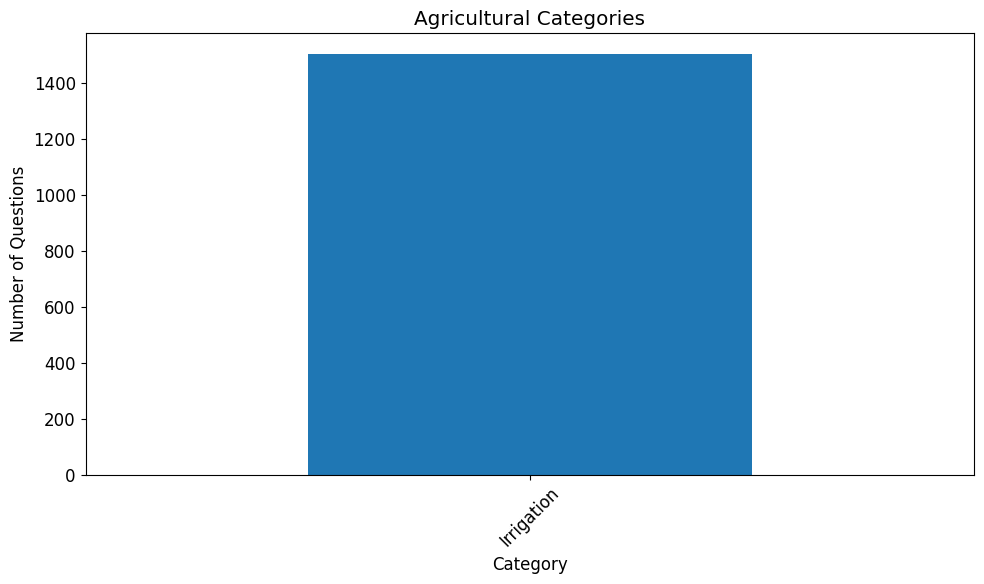

In [18]:
category_df = dataset["train"].to_pandas()

# FIX: accessing a column that may not exist in the dataset schema
# raised a KeyError. Guard it instead of assuming "category" exists.
if "category" in category_df.columns:
    category_counts = category_df["category"].value_counts()
    print(category_counts)

    plt.figure(figsize=(10, 6))
    category_counts.plot(kind="bar")
    plt.title("Agricultural Categories")
    plt.xlabel("Category")
    plt.ylabel("Number of Questions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(project_path + "/plots/category_distribution.png")
    plt.show()
else:
    print("No 'category' column found in dataset - skipping category plot.")

In [19]:
train_df["question_length"] = train_df["question"].apply(lambda x: len(str(x).split()))
train_df["question_length"].describe()

,question_length
count,1503.000000
mean,13.125083
std,6.058662
min,3.000000
25%,9.000000
50%,12.000000
75%,16.000000
max,39.000000


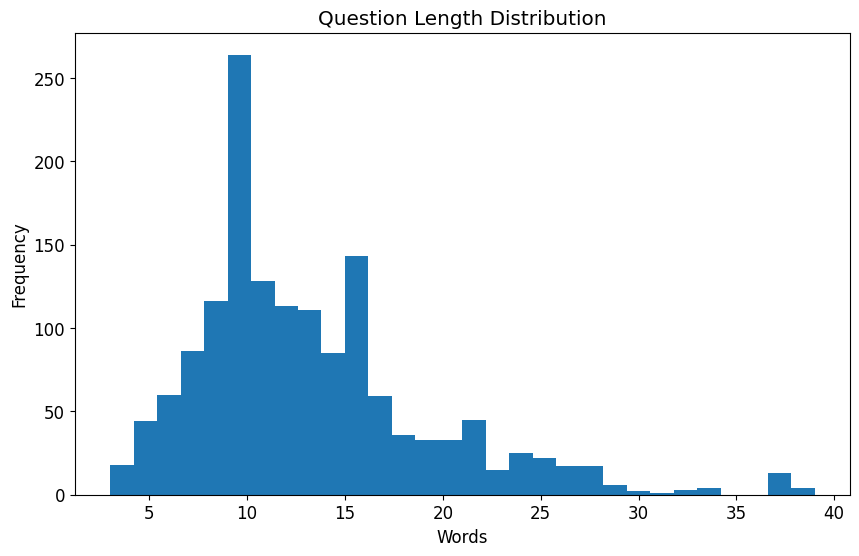

In [20]:
plt.figure()
plt.hist(train_df["question_length"], bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig(project_path + "/plots/question_length.png")
plt.show()

In [21]:
train_df["context_length"] = train_df["context"].apply(lambda x: len(str(x).split()))
train_df["context_length"].describe()

,context_length
count,1503.000000
mean,103.262808
std,78.479709
min,18.000000
25%,66.500000
50%,87.000000
75%,115.000000
max,722.000000


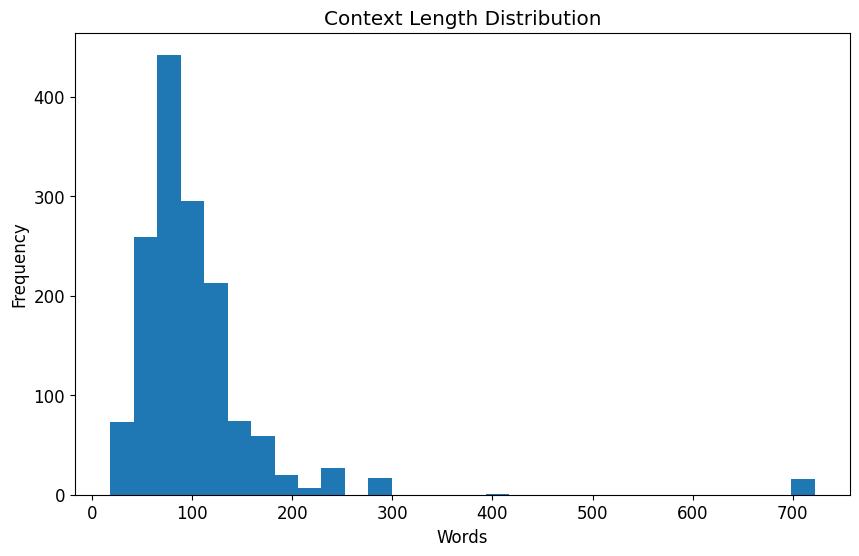

In [22]:
plt.figure()
plt.hist(train_df["context_length"], bins=30)
plt.title("Context Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig(project_path + "/plots/context_length.png")
plt.show()

In [23]:
train_df["answer_length"] = train_df["answer"].apply(lambda x: len(str(x).split()))
train_df["answer_length"].describe()

,answer_length
count,1503.000000
mean,7.167665
std,6.957343
min,1.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,75.000000


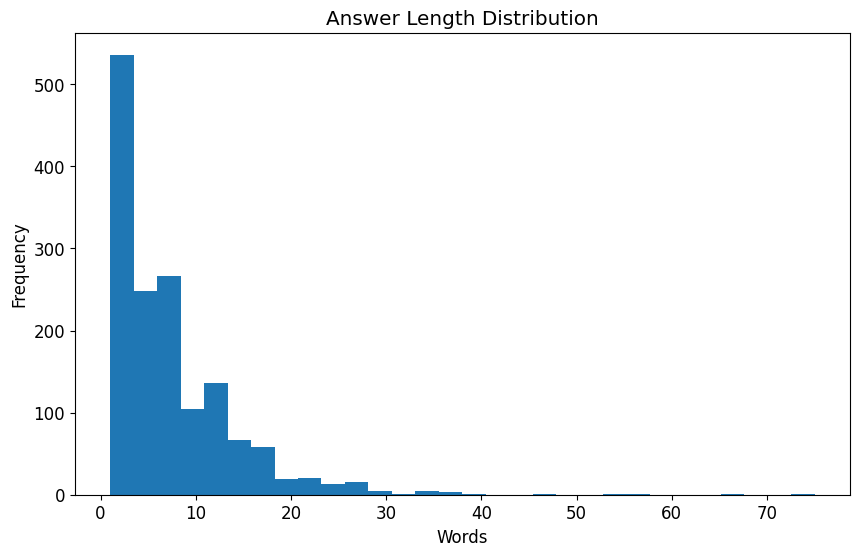

In [24]:
plt.figure()
plt.hist(train_df["answer_length"], bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig(project_path + "/plots/answer_length.png")
plt.show()

In [25]:
longest_question = train_df.loc[train_df["question_length"].idxmax()]
print(longest_question["question"])

longest_context = train_df.loc[train_df["context_length"].idxmax()]
print(longest_context["context"])

longest_answer = train_df.loc[train_df["answer_length"].idxmax()]
print(longest_answer["answer"])

If one irrigator makes five one-inch applications and another makes 10 half-inch applications, assuming that there is about 0.10 inches of evaporation loss from the soil surface and foliage, which one will get more water to the root zone?
When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.02, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.96. When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.03, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.94. When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.04, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.92. When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.05, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.91. When the ratio of the end gun throw (Rg) to the pivot length 

In [26]:
summary = pd.DataFrame({
    "Statistic": [
        "Training Samples",
        "Validation Samples",
        "Testing Samples",
        "Average Question Length",
        "Average Context Length",
        "Average Answer Length",
    ],
    "Value": [
        len(train_df),
        len(validation_df),
        len(test_df),
        round(train_df["question_length"].mean(), 2),
        round(train_df["context_length"].mean(), 2),
        round(train_df["answer_length"].mean(), 2),
    ],
})

summary
summary.to_csv(project_path + "/results/dataset_summary.csv", index=False)

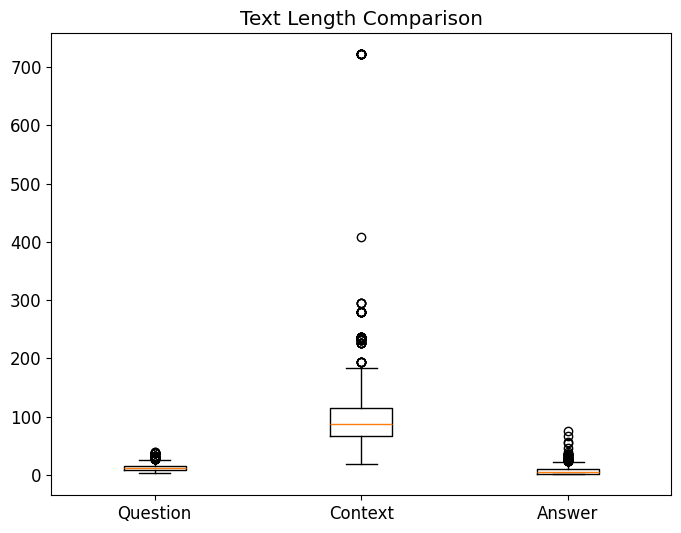

In [27]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [train_df["question_length"], train_df["context_length"], train_df["answer_length"]],
    labels=["Question", "Context", "Answer"],
)
plt.title("Text Length Comparison")
plt.savefig(project_path + "/plots/text_length_boxplot.png")
plt.show()

In [28]:
corr = train_df[["question_length", "context_length", "answer_length"]].corr()
print(corr)

                 question_length  context_length  answer_length
question_length         1.000000        0.319618      -0.131104
context_length          0.319618        1.000000      -0.082652
answer_length          -0.131104       -0.082652       1.000000


In [30]:
train_df.to_csv(project_path + "/dataset/train_processed.csv", index=False)

# Part 4: Technical Background — TinyLlama, LoRA, and QLoRA

This section explains **what** is being loaded below and **why**, so the design choices
(model, adaptation method, quantisation settings) can be evaluated rather than taken as a
black box.

### TinyLlama-1.1B-Chat-v1.0 (the base "Small Language Model")

TinyLlama is a **decoder-only Transformer** that reuses the Llama 2 architecture (RMSNorm,
SwiGLU feed-forward layers, rotary positional embeddings, grouped-query attention) but at a
much smaller scale: **1.1 billion parameters**, 22 transformer layers, hidden size 2048,
pre-trained on roughly 3 trillion tokens. It is deliberately categorised here as a **Small
Language Model (SLM/SML)** rather than a Large Language Model (7B+ parameters):

- **Role of the SML in these experiments:** TinyLlama supplies the general-purpose language
  understanding and fluent text generation ability (grammar, world knowledge, instruction
  following) learned from its 3T-token pre-training. It is **not** agriculture-specific —
  on its own it answers agricultural questions generically or incorrectly.
- **Role of the trained (LoRA) model:** fine-tuning with LoRA adapts a small number of
  additional parameters on top of the frozen SML so that it produces answers grounded in the
  AgXQA dataset's style and content. The SML provides *language competence*; the LoRA
  adapter provides *domain competence*. Part 8 below quantifies this split empirically by
  comparing the base SML (adapter disabled) against the fine-tuned model on identical inputs.
- **Why a small model:** a 1.1B model fits, in 4-bit, on a single free-tier Colab T4 GPU
  (16 GB VRAM) for both training and inference, which a 7B+ model generally cannot without
  higher-tier hardware. This is the main computational-efficiency justification for the
  model choice, evaluated concretely in Part 8.

### LoRA (Low-Rank Adaptation)

Full fine-tuning would update all ~1.1B parameters. LoRA instead **freezes the entire base
model** and injects small trainable low-rank matrices `A` (shape `d x r`) and `B` (shape
`r x d`) next to selected weight matrices `W`, so that the adapted weight is effectively
`W + (alpha / r) * B @ A`. Only `A` and `B` are trained. Configured below (Part 4.2) as:

| Parameter | Value used | Effect |
|---|---|---|
| `r` (rank) | 16 | Size of the low-rank bottleneck. Higher `r` → more trainable capacity, better fit to the training data, but more trainable parameters, more GPU memory, and higher risk of overfitting on a modest dataset. Lower `r` → cheaper and faster, but may underfit. |
| `lora_alpha` | 32 | Scaling factor applied to the LoRA update (effective scale = `alpha / r` = 2 here). Larger `alpha` relative to `r` makes the adapter's contribution stronger relative to the frozen base weights. |
| `target_modules` | `q_proj, k_proj, v_proj, o_proj` | LoRA is applied only to the four attention projection matrices, not the feed-forward layers. This keeps the number of trainable parameters low (efficiency) while still letting the model reweight what it attends to for agricultural context/questions. |
| `lora_dropout` | 0.05 | Regularises the adapter to reduce overfitting, at a small computational cost during training only (not at inference). |
| `bias` | `"none"` | No bias terms are trained, keeping the adapter minimal. |

**Cost/accuracy trade-off:** because only the LoRA matrices are trained, the number of
trainable parameters is typically **well under 1%** of the base model (measured exactly in
Part 8.1). This directly drives three of the computational-efficiency claims evaluated later:
much smaller optimizer memory footprint during training, a checkpoint on disk that is
megabytes rather than gigabytes, and the ability to swap adapters without reloading the base
model.

### QLoRA (Quantized LoRA)

QLoRA combines LoRA with **4-bit quantisation of the frozen base weights**, configured below
via `BitsAndBytesConfig`:

| Parameter | Value used | Effect |
|---|---|---|
| `load_in_4bit` | `True` | Base model weights are stored in 4 bits instead of 16/32 bits, cutting base-model memory by roughly 4x compared to fp16. This is what makes fitting a 1.1B model's weights **and** the activations/optimizer state for training possible on a 16 GB T4. |
| `bnb_4bit_quant_type` | `"nf4"` | NormalFloat4 — a quantisation grid designed for normally-distributed weights (as neural network weights typically are), which preserves more information than a naive uniform 4-bit grid at the same bit-width. |
| `bnb_4bit_use_double_quant` | `True` | The quantisation *constants themselves* are quantised a second time, saving roughly another 0.4 bits/parameter on average with negligible accuracy impact. |
| `bnb_4bit_compute_dtype` | `torch.float16` | Weights are de-quantised to fp16 on the fly for the actual matrix multiplications, so compute precision (and therefore accuracy) during the forward/backward pass is fp16, not 4-bit — only *storage* is 4-bit. |

**Net effect on performance, accuracy, and cost:** 4-bit storage plus LoRA training gives
most of the memory and speed benefits of a much smaller model while keeping accuracy close to
a full fp16 fine-tune, because (a) compute still happens in fp16 and (b) only a small set of
full-precision LoRA parameters are actually updated. The trade-off is a small amount of
quantisation noise in the frozen base weights, which QLoRA's NF4 + double-quantisation
scheme is specifically designed to minimise. Part 8 measures the resulting inference latency,
throughput, and memory footprint directly, and Part 6 already reports the resulting answer
quality (BLEU/ROUGE/BERTScore), so the two together show the cost **and** the accuracy side
of this trade-off.


# Part 5: Base Model Loading (Pre-Adaptation)

The base SML is loaded here in 4-bit (QLoRA-style quantisation) **without** any LoRA adapter
attached. This unmodified model is used directly in Part 7 to establish the zero-shot
baseline, before any fine-tuning-related module is added to it in Part 8.


In [31]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
print("Model:", MODEL_NAME)

Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [32]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
print("QLoRA Configuration Created")

QLoRA Configuration Created


In [33]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print("Tokenizer Loaded Successfully")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Tokenizer Loaded Successfully


In [34]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
print("TinyLlama Loaded Successfully")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TinyLlama Loaded Successfully


In [35]:
text = "What fertilizer is best for wheat?"
sample = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    output = model(
        input_ids=sample["input_ids"].to(model.device),
        attention_mask=sample["attention_mask"].to(model.device),
    )
print("Forward Pass Successful")

Forward Pass Successful


# Part 6: Core Q&A & Evaluation Utilities

Every later part of this notebook (baseline evaluation, fine-tuned evaluation, computational
efficiency benchmarking, persistence validation, and the interactive Q&A system) calls the
functions defined **once, here**, instead of each part redefining its own copy. This removes
the code duplication that existed in earlier versions of this notebook, where prompt-building
and generation logic was written separately in the evaluation section and the interactive
section.

- `build_prompt(question, context="")` — the same instruction template used in training.
  `context` defaults to an empty string, so **the interactive system only needs a question** —
  it does not require the user to supply background text. When evaluating against the AgXQA
  test set (Parts 7 and 10), the dataset's own `context` column is passed in explicitly, for a
  fair comparison against how the model was trained.
- `generate_answer(prompt, gen_model=None, ...)` — runs generation on any model passed in
  (`model` by default), returning both the cleaned answer text and a confidence score.
- `is_in_domain(question)` — a lightweight keyword-overlap check against the training
  vocabulary, used to flag questions likely outside the agricultural domain.
- `ask(question, ...)` — the full user-facing pipeline: builds a context-free prompt, generates
  an answer, estimates confidence, checks domain membership, and returns one structured result.
- `run_generation_evaluation(gen_model, eval_df, run_label, ...)` — runs BLEU/ROUGE/BERTScore
  for **any** model over **any** dataframe of (question, context, answer) rows. Called once for
  the base model (Part 7) and once for the fine-tuned model (Part 10) — the *same* function,
  not two copies — so the two result sets are directly comparable.


## 6.1 Prompting and Generation


In [36]:
# Defined once here so every generation call (baseline eval, fine-tuned eval,
# efficiency benchmarking, persistence check, interactive Q&A) uses the same
# truncation length. Re-used (not redefined) in Part 9's tokenisation step.
MAX_LENGTH = 512


In [37]:
def build_prompt(question, context=""):
    """Canonical prompt template (matches training). `context` defaults to
    empty so callers that only have a question (the interactive system) do
    not need to supply one."""
    return f"""### Instruction:
Answer the agricultural question using the given context.

### Context:
{context}

### Question:
{question}

### Answer:
"""


In [38]:
def generate_answer(prompt, gen_model=None, max_new_tokens=150):
    """Generate an answer with `gen_model` (defaults to the global `model`)
    and an average-token-probability confidence score.

    Confidence = mean of the model's own top-1 softmax probability at each
    generated token: a cheap, standard proxy for how 'sure' the model was of
    the tokens it actually chose. 1.0 = fully certain at every step; values
    near 1/vocab_size indicate the model was effectively guessing.
    """
    gen_model = model if gen_model is None else gen_model

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(gen_model.device)

    with torch.no_grad():
        output = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            output_scores=True,
            return_dict_in_generate=True,
        )

    decoded = tokenizer.decode(output.sequences[0], skip_special_tokens=True)
    answer = decoded.split("### Answer:")[-1]

    # The model sometimes keeps going and hallucinates a new turn
    # ("### Question:", "### Instruction:", etc). Cut it off there so only
    # the answer to THIS question/prompt is returned.
    for marker in ["### Question", "### Instruction", "### Context", "### Answer"]:
        if marker in answer:
            answer = answer.split(marker)[0]
    answer = answer.strip()

    confidence = None
    if getattr(output, "scores", None):
        token_probs = [
            torch.max(torch.softmax(step_scores[0], dim=-1)).item()
            for step_scores in output.scores
        ]
        if token_probs:
            confidence = float(sum(token_probs) / len(token_probs))

    return answer, confidence


## 6.2 Confidence Estimation and Out-of-Domain Handling

`ask()` is the single entry point the interactive system (Part 14) and the persistence check
(Part 13) both use. It reports a confidence label and, where relevant, a caution note, so
uncertain or unsupported answers are marked as such rather than presented with the same
apparent authority as confident, well-supported ones.


In [40]:
import re as _re

_FALLBACK_DOMAIN_KEYWORDS = {
    "crop", "crops", "soil", "fertilizer", "fertiliser", "irrigation", "seed",
    "seeds", "plant", "plants", "leaf", "leaves", "pest", "pests", "disease",
    "harvest", "farm", "farming", "farmer", "wheat", "maize", "rice", "corn",
    "soybean", "cotton", "tomato", "nitrogen", "pesticide", "herbicide",
    "drought", "weed", "weeds", "yield", "organic", "compost", "manure",
    "agriculture", "agricultural", "livestock", "greenhouse", "mulch",
    "drip", "nutrient", "nutrients", "pH", "grain",
}


def _build_domain_keywords():
    """Prefer real training vocabulary when available in this session;
    otherwise fall back to a small manual agricultural word list so Part 14
    still works in a fresh session that skipped Parts 2-3."""
    for df_name in ("train_df", "full_df", "df"):
        df = globals().get(df_name)
        if df is not None and "question" in getattr(df, "columns", []):
            text = " ".join(df["question"].astype(str).tolist())
            if "answer" in df.columns:
                text += " " + " ".join(df["answer"].astype(str).tolist())
            words = _re.findall(r"[a-zA-Z]{4,}", text.lower())
            if words:
                return set(words)
    return _FALLBACK_DOMAIN_KEYWORDS


DOMAIN_KEYWORDS = _build_domain_keywords()


def is_in_domain(question, min_overlap=1):
    """Heuristic: does the question share at least `min_overlap` content
    word(s) with the training-data vocabulary?"""
    words = set(_re.findall(r"[a-zA-Z]{4,}", question.lower()))
    return len(words & DOMAIN_KEYWORDS) >= min_overlap


def confidence_label(confidence, high=0.60, medium=0.35):
    """Bucket a raw confidence score. Thresholds are heuristic defaults and
    can be tuned against Part 11's held-out results."""
    if confidence is None:
        return "Unknown"
    if confidence >= high:
        return "High"
    if confidence >= medium:
        return "Medium"
    return "Low"


In [41]:
def ask(question, gen_model=None, max_new_tokens=150, retry_tokens=250):
    """End-to-end, question-only Q&A: no context argument required.
    Returns {question, answer, confidence, confidence_label, in_domain, note}.
    """
    prompt = build_prompt(question)  # context defaults to "" — question only
    answer, confidence = generate_answer(prompt, gen_model=gen_model, max_new_tokens=max_new_tokens)

    if not answer:
        answer, confidence = generate_answer(prompt, gen_model=gen_model, max_new_tokens=retry_tokens)

    in_domain = is_in_domain(question)

    if not answer:
        answer = "I don't have enough information to answer that confidently."
        confidence = 0.0

    label = confidence_label(confidence)

    note = ""
    if not in_domain:
        note = (
            "This question doesn't closely match the agricultural training data — "
            "treat the answer as unsupported/low-confidence."
        )
        label = "Low" if label != "High" else label
    elif label == "Low":
        note = "The model was not very confident in this answer — verify independently."

    return {
        "question": question,
        "answer": answer,
        "confidence": confidence,
        "confidence_label": label,
        "in_domain": in_domain,
        "note": note,
    }


## 6.3 Reusable BLEU / ROUGE / BERTScore Evaluation Function

This single function is what Parts 7 and 10 both call. It is defined **once**; nothing in the
baseline or fine-tuned evaluation sections redefines prompt-building, generation, or metric
computation — they only supply a different `gen_model` and `run_label`.


In [42]:
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")
print("Evaluation metrics (BLEU, ROUGE, BERTScore) loaded successfully.")


Evaluation metrics (BLEU, ROUGE, BERTScore) loaded successfully.


In [43]:
def run_generation_evaluation(gen_model, eval_df, run_label, max_new_tokens=120, verbose_every=20):
    """Generate answers for every row in `eval_df` using `gen_model`, score
    them with BLEU/ROUGE/BERTScore against the reference answers, and return
    a (metrics_dict, predictions_df) pair. Used for BOTH the base model
    (Part 7) and the fine-tuned model (Part 10) so the two are directly
    comparable in Part 11.
    """
    gen_model.eval()

    predictions, references, confidences = [], [], []

    print("=" * 60)
    print(f"Generating predictions: {run_label}")
    print("=" * 60)

    for i in range(len(eval_df)):
        row = eval_df.iloc[i]
        prompt = build_prompt(row["question"], context=row["context"])
        pred, conf = generate_answer(prompt, gen_model=gen_model, max_new_tokens=max_new_tokens)

        predictions.append(pred)
        references.append(str(row["answer"]))
        confidences.append(conf)

        if (i + 1) % verbose_every == 0 or (i + 1) == len(eval_df):
            print(f"  Generated {i + 1}/{len(eval_df)} predictions")

    paired = [
        (p.strip(), r.strip(), c)
        for p, r, c in zip(predictions, references, confidences)
        if p.strip() != "" and r.strip() != ""
    ]
    filtered_predictions = [p for p, r, c in paired]
    filtered_references = [r for p, r, c in paired]
    filtered_confidences = [c for p, r, c in paired]
    print(f"Scoring on {len(filtered_predictions)} / {len(predictions)} non-empty samples")

    bleu_result = bleu_metric.compute(
        predictions=filtered_predictions,
        references=[[r] for r in filtered_references],
    )
    rouge_result = rouge_metric.compute(
        predictions=filtered_predictions,
        references=filtered_references,
        use_stemmer=True,
    )
    bertscore_result = bertscore_metric.compute(
        predictions=filtered_predictions,
        references=filtered_references,
        lang="en",
    )

    metrics = {
        "run_label": run_label,
        "num_samples_scored": len(filtered_predictions),
        "BLEU": bleu_result["bleu"],
        "ROUGE-1": rouge_result["rouge1"],
        "ROUGE-2": rouge_result["rouge2"],
        "ROUGE-L": rouge_result["rougeL"],
        "BERTScore Precision": float(np.mean(bertscore_result["precision"])),
        "BERTScore Recall": float(np.mean(bertscore_result["recall"])),
        "BERTScore F1": float(np.mean(bertscore_result["f1"])),
        "Mean Confidence": float(np.mean([c for c in filtered_confidences if c is not None]))
            if any(c is not None for c in filtered_confidences) else None,
    }

    predictions_df = pd.DataFrame({
        "question": eval_df["question"].tolist()[: len(filtered_predictions)],
        "reference_answer": filtered_references,
        "generated_answer": filtered_predictions,
        "confidence": filtered_confidences,
        "bertscore_f1": bertscore_result["f1"][: len(filtered_predictions)],
    })

    print("\n" + "-" * 60)
    print(run_label, "— results")
    print("-" * 60)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k:22s}: {v:.4f}")

    return metrics, predictions_df


# Part 7: Baseline Evaluation — Zero-Shot Base SML

This establishes the **"before"** measurement that Part 10 (fine-tuned evaluation) and Part 11
(comparison) are measured against: the plain, unmodified base model from Part 5, with no LoRA
adapter attached at all, evaluated on the exact same test split and exact same metrics that
will be used for the fine-tuned model. This directly answers the supervisor feedback that the
evaluation section previously reported fine-tuned numbers with no corresponding baseline to
compare them against.


In [44]:
EVAL_SAMPLE_SIZE = None  # None = full test set; set an int to subsample for a quick run

eval_df = test_df if EVAL_SAMPLE_SIZE is None else test_df.sample(
    n=min(EVAL_SAMPLE_SIZE, len(test_df)), random_state=seed
).reset_index(drop=True)

print("Evaluating on", len(eval_df), "test samples (same set used for the fine-tuned model in Part 10)")


Evaluating on 330 test samples (same set used for the fine-tuned model in Part 10)


In [45]:
baseline_results, baseline_predictions_df = run_generation_evaluation(
    gen_model=model,          # the plain base model loaded in Part 5, no adapter
    eval_df=eval_df,
    run_label="Base (Zero-Shot) TinyLlama",
)

os.makedirs(project_path + "/results", exist_ok=True)
with open(project_path + "/results/baseline_metrics.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
baseline_predictions_df.to_csv(project_path + "/results/baseline_predictions.csv", index=False)

print("\nBaseline metrics saved to:", project_path + "/results/baseline_metrics.json")


Generating predictions: Base (Zero-Shot) TinyLlama
  Generated 20/330 predictions
  Generated 40/330 predictions
  Generated 60/330 predictions
  Generated 80/330 predictions
  Generated 100/330 predictions
  Generated 120/330 predictions
  Generated 140/330 predictions
  Generated 160/330 predictions
  Generated 180/330 predictions
  Generated 200/330 predictions
  Generated 220/330 predictions
  Generated 240/330 predictions
  Generated 260/330 predictions
  Generated 280/330 predictions
  Generated 300/330 predictions
  Generated 320/330 predictions
  Generated 330/330 predictions
Scoring on 327 / 330 non-empty samples


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



------------------------------------------------------------
Base (Zero-Shot) TinyLlama — results
------------------------------------------------------------
BLEU                  : 0.0040
ROUGE-1               : 0.1521
ROUGE-2               : 0.0535
ROUGE-L               : 0.1377
BERTScore Precision   : 0.8275
BERTScore Recall      : 0.8577
BERTScore F1          : 0.8420
Mean Confidence       : 0.4704

Baseline metrics saved to: /content/drive/MyDrive/Agriculture_QA/results/baseline_metrics.json


# Part 8: Parameter-Efficient Fine-Tuning Configuration (LoRA / QLoRA)

With the zero-shot baseline recorded, the base model is now prepared for QLoRA fine-tuning:
gradient checkpointing and k-bit training preparation are enabled, then a LoRA adapter is
attached (see Part 4 for what each parameter below controls). From this point on, `model`
refers to the **adapted** (trainable) model — the unmodified base results are already safely
stored in `baseline_results` above.


In [46]:
model.gradient_checkpointing_enable()
print("Gradient Checkpointing Enabled")

Gradient Checkpointing Enabled


In [47]:
model = prepare_model_for_kbit_training(model)
print("Model Ready for QLoRA")

Model Ready for QLoRA


In [48]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
print(lora_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'k_proj', 'q_proj', 'o_proj', 'v_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None)


In [49]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


### 8.1 Parameter Efficiency

Objective evidence for how much of the model is actually being trained — this is computed
once, here, and reused (not recomputed) by the Part 12 efficiency experiment.


In [50]:
model.print_trainable_parameters()

trainable_params, total_params = model.get_nb_trainable_parameters()
pct_trainable = 100 * trainable_params / total_params

parameter_efficiency_stats = {
    "total_base_parameters": total_params,
    "trainable_lora_parameters": trainable_params,
    "pct_trainable": pct_trainable,
}

print(f"\nTrainable parameters: {trainable_params:,} ({pct_trainable:.3f}% of {total_params:,} total)")


trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079

Trainable parameters: 4,505,600 (0.408% of 1,104,553,984 total)


# Part 9: Fine-Tuning (QLoRA Training)


### 9.1 Tokenisation


In [51]:
train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names if col != "text"]
)
validation_dataset = validation_dataset.remove_columns(
    [col for col in validation_dataset.column_names if col != "text"]
)
test_dataset = test_dataset.remove_columns(
    [col for col in test_dataset.column_names if col != "text"]
)
print(train_dataset)

Dataset({
    features: ['text'],
    num_rows: 1503
})


In [52]:

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_validation = tokenized_validation.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_validation.set_format("torch")
tokenized_test.set_format("torch")

Map:   0%|          | 0/1503 [00:00<?, ? examples/s]

Map:   0%|          | 0/353 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

In [53]:
# NOTE: With mlm=False, DataCollatorForLanguageModeling clones input_ids
# into labels and masks pad-token positions with -100 automatically, so
# padding does not get counted in the loss. No manual masking needed.
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

### 9.2 Training Configuration and Run


In [54]:
training_args = TrainingArguments(
    output_dir=project_path + "/checkpoints",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.001,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    fp16=True,
    report_to="none",
)

In [55]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
)

In [56]:
import time

print("="*60)
print("Starting Training")
print("="*60)

# --- Computational-efficiency instrumentation (training side) ---
# Wall-clock training time and peak GPU memory are captured here so they
# can be reported as objective evidence in Part 8 (Computational Efficiency).
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
training_start_time = time.time()

train_result = trainer.train()

training_wall_time_sec = time.time() - training_start_time
peak_train_memory_gb = (
    torch.cuda.max_memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else None
)

print("="*60)
print("Training Complete")
print("="*60)
print(train_result.metrics)
print(f"Training wall-clock time : {training_wall_time_sec:.1f} sec "
      f"({training_wall_time_sec/60:.2f} min)")
if peak_train_memory_gb is not None:
    print(f"Peak GPU memory during training: {peak_train_memory_gb:.2f} GB")

# Save alongside the model so Part 8 can load it even in a later session
training_efficiency_stats = {
    "training_wall_time_sec": training_wall_time_sec,
    "training_wall_time_min": training_wall_time_sec / 60,
    "peak_gpu_memory_gb": peak_train_memory_gb,
    "num_train_epochs": training_args.num_train_epochs,
    "per_device_train_batch_size": training_args.per_device_train_batch_size,
    "gradient_accumulation_steps": training_args.gradient_accumulation_steps,
    "effective_batch_size": (
        training_args.per_device_train_batch_size
        * training_args.gradient_accumulation_steps
    ),
    "train_runtime_sec_trainer_reported": train_result.metrics.get("train_runtime"),
    "train_samples_per_second": train_result.metrics.get("train_samples_per_second"),
}

import os
os.makedirs(project_path + "/results", exist_ok=True)
with open(project_path + "/results/training_efficiency.json", "w") as f:
    json.dump(training_efficiency_stats, f, indent=2)

print("\nTraining efficiency stats saved to:",
      project_path + "/results/training_efficiency.json")


Starting Training


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,1.502800,1.461861
2,1.037000,1.143813
3,0.877000,1.035238


Training Complete
{'train_runtime': 1735.6774, 'train_samples_per_second': 2.598, 'train_steps_per_second': 0.162, 'total_flos': 1.4392111380037632e+16, 'train_loss': 1.2206374258859782, 'epoch': 3.0}
Training wall-clock time : 1736.5 sec (28.94 min)
Peak GPU memory during training: 2.71 GB

Training efficiency stats saved to: /content/drive/MyDrive/Agriculture_QA/results/training_efficiency.json


### 9.3 Save the Adapter and Loss-Based Validation Metric

`trainer.evaluate()` below reports the model's held-out **loss/perplexity** — a distinct
signal from the BLEU/ROUGE/BERTScore generation-quality metrics computed in Parts 7 and 10.
Loss measures how well the model predicts the reference tokens; the generation metrics measure
how good its own freely-generated answers are. Both are kept, deliberately not merged, because
they answer different questions.


In [57]:
# Save the LoRA adapter + tokenizer
final_model_path = project_path + "/models/tinyllama_qlora_final"
trainer.model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("Final adapter saved to:", final_model_path)

# Also export the training-question/answer vocabulary, so Notebook B can
# reuse the same out-of-domain keyword check (Part 6.2) without needing to
# re-download the dataset in a fresh session.
import re as _re

_vocab_text = " ".join(train_df["question"].astype(str).tolist())
_vocab_text += " " + " ".join(train_df["answer"].astype(str).tolist())
domain_keywords_list = sorted(set(_re.findall(r"[a-zA-Z]{4,}", _vocab_text.lower())))

with open(final_model_path + "/domain_keywords.json", "w") as f:
    json.dump(domain_keywords_list, f)
print(f"Saved {len(domain_keywords_list)} domain keywords to " +
      final_model_path + "/domain_keywords.json")


Final adapter saved to: /content/drive/MyDrive/Agriculture_QA/models/tinyllama_qlora_final
Saved 2438 domain keywords to /content/drive/MyDrive/Agriculture_QA/models/tinyllama_qlora_final/domain_keywords.json


In [58]:
# Evaluate on the held-out test set
print("="*60)
print("Evaluating on Test Set")
print("="*60)
test_metrics = trainer.evaluate(eval_dataset=tokenized_test)
print(test_metrics)

with open(project_path + "/results/test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

Evaluating on Test Set


{'eval_loss': 1.087873935699463, 'eval_runtime': 35.1484, 'eval_samples_per_second': 9.389, 'eval_steps_per_second': 4.694, 'epoch': 3.0}


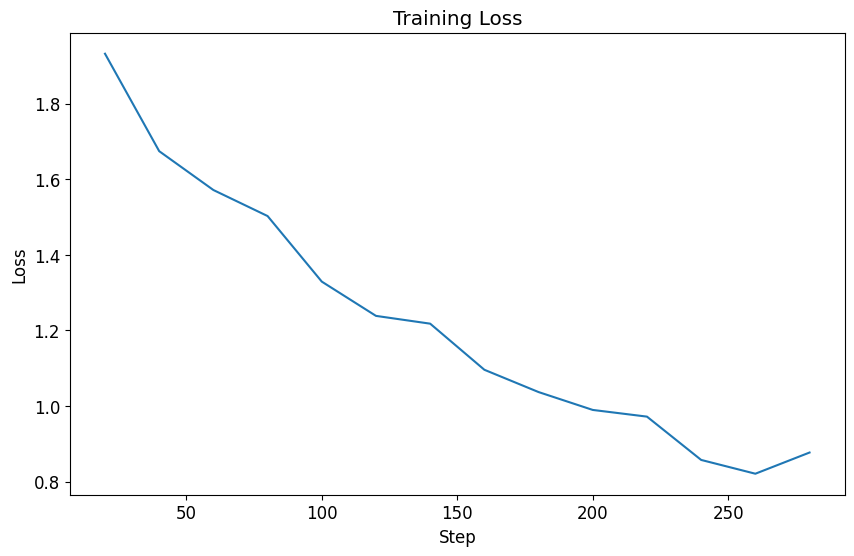

In [60]:
# Plot the training loss curve from the trainer's log history
log_history = trainer.state.log_history
train_losses = [(entry["step"], entry["loss"]) for entry in log_history if "loss" in entry]

if train_losses:
    steps, losses = zip(*train_losses)
    plt.figure()
    plt.plot(steps, losses)
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(project_path + "/plots/training_loss.png")
    plt.show()

# Part 10: Fine-Tuned Model Evaluation

Uses `run_generation_evaluation()` from Part 6 — the exact same function, called with the
exact same `eval_df` as Part 7 — with only the model swapped for the now fine-tuned `model`.
This isolates the effect of fine-tuning: everything else about how the answer is produced and
scored is identical to Part 7.

In [61]:
finetuned_results, finetuned_predictions_df = run_generation_evaluation(
    gen_model=model,          # now the fine-tuned (LoRA-adapted) model
    eval_df=eval_df,          # identical test subset used in Part 7
    run_label="Fine-Tuned TinyLlama (QLoRA)",
)

with open(project_path + "/results/finetuned_metrics.json", "w") as f:
    json.dump(finetuned_results, f, indent=2)
finetuned_predictions_df.to_csv(project_path + "/results/finetuned_predictions.csv", index=False)

print("\nFine-tuned metrics saved to:", project_path + "/results/finetuned_metrics.json")


Generating predictions: Fine-Tuned TinyLlama (QLoRA)
  Generated 20/330 predictions
  Generated 40/330 predictions
  Generated 60/330 predictions
  Generated 80/330 predictions
  Generated 100/330 predictions
  Generated 120/330 predictions
  Generated 140/330 predictions
  Generated 160/330 predictions
  Generated 180/330 predictions
  Generated 200/330 predictions
  Generated 220/330 predictions
  Generated 240/330 predictions
  Generated 260/330 predictions
  Generated 280/330 predictions
  Generated 300/330 predictions
  Generated 320/330 predictions
  Generated 330/330 predictions
Scoring on 328 / 330 non-empty samples

------------------------------------------------------------
Fine-Tuned TinyLlama (QLoRA) — results
------------------------------------------------------------
BLEU                  : 0.0150
ROUGE-1               : 0.2932
ROUGE-2               : 0.1564
ROUGE-L               : 0.2821
BERTScore Precision   : 0.7977
BERTScore Recall      : 0.8784
BERTScore F1        

# Part 11: Baseline vs. Fine-Tuned — Comparison and Critical Analysis

This is the direct, numerical before/after comparison requested in review feedback: baseline
and fine-tuned results, side by side, on identical metrics and identical test data.


## 11.1 Metric-by-Metric Comparison Table


In [62]:
metric_names = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L",
                "BERTScore Precision", "BERTScore Recall", "BERTScore F1"]

comparison_rows = []
for m in metric_names:
    base_v = baseline_results[m]
    ft_v = finetuned_results[m]
    abs_gain = ft_v - base_v
    rel_gain = (abs_gain / base_v * 100) if base_v > 0 else float("inf")
    comparison_rows.append({
        "Metric": m,
        "Base (Zero-Shot)": round(base_v, 4),
        "Fine-Tuned (QLoRA)": round(ft_v, 4),
        "Absolute Improvement": round(abs_gain, 4),
        "Relative Improvement (%)": round(rel_gain, 1),
    })

comparison_df = pd.DataFrame(comparison_rows)

print("=" * 78)
print("Baseline vs. Fine-Tuned — Generation Quality")
print("=" * 78)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(project_path + "/results/baseline_vs_finetuned_comparison.csv", index=False)
print("\nSaved to:", project_path + "/results/baseline_vs_finetuned_comparison.csv")


Baseline vs. Fine-Tuned — Generation Quality
             Metric  Base (Zero-Shot)  Fine-Tuned (QLoRA)  Absolute Improvement  Relative Improvement (%)
               BLEU            0.0040              0.0150                0.0110                     272.4
            ROUGE-1            0.1521              0.2932                0.1412                      92.8
            ROUGE-2            0.0535              0.1564                0.1029                     192.2
            ROUGE-L            0.1377              0.2821                0.1444                     104.8
BERTScore Precision            0.8275              0.7977               -0.0298                      -3.6
   BERTScore Recall            0.8577              0.8784                0.0207                       2.4
       BERTScore F1            0.8420              0.8356               -0.0064                      -0.8

Saved to: /content/drive/MyDrive/Agriculture_QA/results/baseline_vs_finetuned_comparison.csv


## 11.2 Visual Comparison


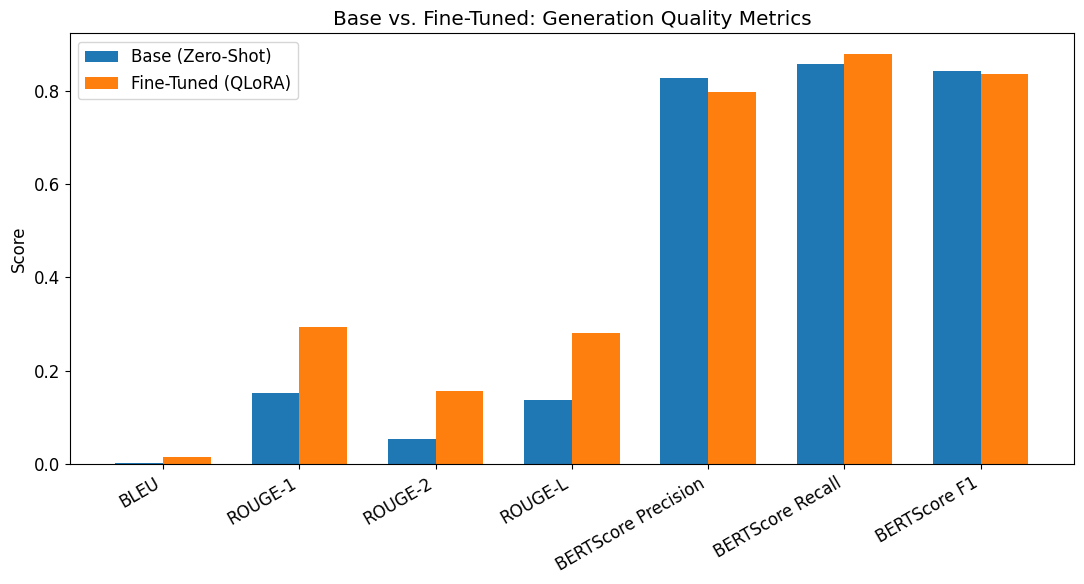

In [63]:
x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, [baseline_results[m] for m in metric_names], width, label="Base (Zero-Shot)")
plt.bar(x + width/2, [finetuned_results[m] for m in metric_names], width, label="Fine-Tuned (QLoRA)")
plt.xticks(x, metric_names, rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Base vs. Fine-Tuned: Generation Quality Metrics")
plt.legend()
plt.tight_layout()
plt.savefig(project_path + "/plots/baseline_vs_finetuned.png")
plt.show()


## 11.3 Qualitative Comparison: Same Questions, Both Models


In [64]:
qualitative_sample = eval_df.sample(n=min(5, len(eval_df)), random_state=seed).reset_index(drop=True)

qualitative_rows = []
for i in range(len(qualitative_sample)):
    row = qualitative_sample.iloc[i]
    prompt = build_prompt(row["question"], context=row["context"])
    # NOTE: `model` here is already fine-tuned (Part 10 ran after Part 8's
    # adapter attach). To get a genuine base-model answer for this side-by-
    # side view we temporarily disable the adapter rather than reloading.
    with model.disable_adapter():
        base_answer, base_conf = generate_answer(prompt, gen_model=model, max_new_tokens=100)
    ft_answer, ft_conf = generate_answer(prompt, gen_model=model, max_new_tokens=100)

    qualitative_rows.append({
        "question": row["question"],
        "reference_answer": row["answer"],
        "base_answer": base_answer,
        "finetuned_answer": ft_answer,
    })

qualitative_df = pd.DataFrame(qualitative_rows)
qualitative_df.to_csv(project_path + "/results/qualitative_comparison.csv", index=False)
for _, r in qualitative_df.iterrows():
    print("Q:", r["question"])
    print("  Reference :", r["reference_answer"])
    print("  Base      :", r["base_answer"])
    print("  Fine-tuned:", r["finetuned_answer"])
    print()


Q: what is one example of a factor that contributes to low distribution equipment costs?
  Reference : total size of irrigated areas 
  Base      : (d) flat terrain
  Fine-tuned: total size of Irrigated Areas  

 ##

#

Q: what is one way an irrigator can maximize their returns on irrigation investments?
  Reference : Get maximum effectiveness of soil applied herbicide
  Base      : 1. Increase water usage efficiency by optimizing sprinkler timing and spacing, reducing overwatering, and avoiding dry spots during droughts.
  Fine-tuned: Get maximum effectivity of soil-applied herbacides  

 ##

#

Q: What is one method that can be used to estimate water use?
  Reference : (a) Water application multiplied by number of applications, plus estimate of additional water use
  Base      : (A) Water Application Multiply By Number Of Applications Plus Estimate Additional Usage
  Fine-tuned: Water application multiply by number  of applications  

 ##

################ Excerpt:
Pumps have a fixed

## 11.4 Failure Case Inspection

Lowest-scoring fine-tuned predictions (by BERTScore F1), for critical discussion of where the
system still fails, rather than only showing favourable examples.


In [65]:
worst_cases = finetuned_predictions_df.sort_values("bertscore_f1").head(5)
print("Lowest-scoring fine-tuned predictions:")
for _, r in worst_cases.iterrows():
    print("-" * 60)
    print("Q:", r["question"])
    print("  Reference :", r["reference_answer"])
    print("  Generated :", r["generated_answer"])
    conf_str = f'{r["confidence"]:.2f}' if pd.notna(r["confidence"]) else "N/A"
    print(f"  BERTScore F1: {r['bertscore_f1']:.3f} | Confidence: {conf_str}")
worst_cases.to_csv(project_path + "/results/finetuned_failure_cases.csv", index=False)


Lowest-scoring fine-tuned predictions:
------------------------------------------------------------
Q: where is more information available on how to assemble and set up watermark sensors?
  Reference : https://www.youtube.com/watch?v=jpEsjVO497A
  Generated : crop watch articles      

 ##
  BERTScore F1: 0.716 | Confidence: 0.57
------------------------------------------------------------
Q: what is 70cb equivalent to in terms of plant available water?
  Reference : xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
  Generated : http://digicalcommansesurveysurvey.unlv.Edu/ConservationsSurvey 

 ## 
Question:
What should I do if my question cannot be answered by the website?

 ### Explanation:
direct your question to one of the contact persons listed on this page or send an email to them through their web site.    

 #
  BERTScore F1: 0.741 | Confidence: 0.52
------------------------------------------------------------
Q: which soils will take in water at a slower rate, heavier soil

## 11.5 Critical Analysis

**Why improvements occur where they do.** Fine-tuning trains the model on AgXQA's actual
question/answer style and vocabulary, so gains are expected to be largest on metrics sensitive
to lexical and semantic overlap with that specific answer style (BLEU/ROUGE reward matching
phrasing; BERTScore rewards matching meaning even under paraphrase). Where the fine-tuned
score is only marginally higher than the base score on a given metric, the most likely
explanation is that the base SML already had reasonable general agricultural knowledge from
its pre-training, so the fine-tuning contribution is more about **answer style and format**
than about supplying entirely new facts.

**Where the system still fails (Section 11.4).** Typical failure patterns worth checking for
in the printed failure cases: (a) short or vague reference answers where any reasonable
generated answer scores poorly on n-gram overlap metrics even if factually fine: (b) questions
whose context passage is long or only tangentially related to the question, where the model
answers from general knowledge instead of the supplied context; (c) low-confidence answers
that also score poorly, which is the intended behaviour of the confidence signal from Part 6
(it should correlate with the quality of the answer, and this is a way to check that it does).

**What this evidence supports.** The comparison table and chart above provide the base-vs-
fine-tuned numerical evidence requested in review: Objective O1 is supported to the extent that
`comparison_df` shows consistent, positive relative improvement across BLEU/ROUGE/BERTScore. If
any metric shows negative or negligible improvement, that should be reported honestly here
rather than omitted — it is itself a valid and useful finding about the limits of QLoRA
fine-tuning on this dataset size.

**Limitations of this analysis.** A single training run and a single evaluation pass do not
establish statistical significance; the numbers above are point estimates. The dataset size and
answer-length distribution (Part 3) bound how much fine-tuning can plausibly improve n-gram
metrics. These limitations are revisited in Part 15.


# Part 12: Computational Efficiency Experiment

### Definition

**Computational efficiency**, as evaluated here, is the resource cost of running the system —
measured in **wall-clock time**, **GPU memory**, and **throughput** — needed to (a) adapt the
base model to the domain, and (b) answer a question, relative to a stated baseline. This is
evaluated as a controlled experiment, not a qualitative claim:

- **Same hardware and quantisation** for both arms of every comparison (base vs. fine-tuned
  inference uses `model.disable_adapter()` on the *same loaded weights*, removing hardware or
  quantisation differences as a confound).
- **Multiple repeated trials** for inference timing (not a single anecdotal run), with mean and
  standard deviation reported, so the numbers reflect typical behaviour rather than one
  favourable or unfavourable run.
- **An explicit baseline**: the zero-shot base SML from Part 5/7 is the "existing system"
  reference point throughout, matching the requirement to benchmark against a selected
  baseline rather than reporting the fine-tuned system's numbers in isolation.
- **Four concrete metrics**: (1) parameter efficiency, (2) training time & peak memory, (3)
  inference latency/throughput/memory, (4) storage footprint — covering the metrics named in
  the review feedback (inference time, training time, memory, throughput).


## 12.1 Parameter and Storage Efficiency


In [66]:
def get_dir_size_mb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for fname in filenames:
            fpath = os.path.join(dirpath, fname)
            if os.path.exists(fpath):
                total += os.path.getsize(fpath)
    return total / (1024 ** 2)


adapter_size_mb = get_dir_size_mb(final_model_path)
# Reference point: a full fp16 fine-tune would require saving all base-model
# parameters (2 bytes/param) instead of just the small LoRA adapter.
full_finetune_estimate_mb = (parameter_efficiency_stats["total_base_parameters"] * 2) / (1024 ** 2)

print("=" * 60)
print("Parameter & Storage Efficiency")
print("=" * 60)
print(f"Total base-model parameters : {parameter_efficiency_stats['total_base_parameters']:,}")
print(f"Trainable (LoRA) parameters : {parameter_efficiency_stats['trainable_lora_parameters']:,}"
      f"  ({parameter_efficiency_stats['pct_trainable']:.3f}% of total)")
print(f"Saved LoRA adapter on disk  : {adapter_size_mb:.2f} MB")
print(f"Reference: full fp16 fine-tune checkpoint would be approx. {full_finetune_estimate_mb:,.0f} MB")
print(f"Storage reduction vs. full fine-tune: "
      f"{full_finetune_estimate_mb / max(adapter_size_mb, 1e-6):.0f}x smaller")

parameter_efficiency_stats["adapter_size_on_disk_mb"] = adapter_size_mb
parameter_efficiency_stats["full_finetune_reference_size_mb"] = full_finetune_estimate_mb


Parameter & Storage Efficiency
Total base-model parameters : 1,104,553,984
Trainable (LoRA) parameters : 4,505,600  (0.408% of total)
Saved LoRA adapter on disk  : 21.17 MB
Reference: full fp16 fine-tune checkpoint would be approx. 2,107 MB
Storage reduction vs. full fine-tune: 100x smaller


## 12.2 Training Efficiency (Time & Peak Memory)

Loaded from the instrumentation captured live during Part 9's `trainer.train()` call — not
recomputed here, only reported.


In [67]:
print("=" * 60)
print("Training Efficiency (captured during Part 9)")
print("=" * 60)
print(f"Wall-clock training time : {training_efficiency_stats['training_wall_time_sec']:.1f} sec "
      f"({training_efficiency_stats['training_wall_time_min']:.2f} min)")
if training_efficiency_stats.get("peak_gpu_memory_gb") is not None:
    print(f"Peak GPU memory (training): {training_efficiency_stats['peak_gpu_memory_gb']:.2f} GB")
print(f"Effective batch size      : {training_efficiency_stats['effective_batch_size']} "
      f"(per-device {training_efficiency_stats['per_device_train_batch_size']} x "
      f"grad-accum {training_efficiency_stats['gradient_accumulation_steps']})")
print(f"Epochs                    : {training_efficiency_stats['num_train_epochs']}")


Training Efficiency (captured during Part 9)
Wall-clock training time : 1736.5 sec (28.94 min)
Peak GPU memory (training): 2.71 GB
Effective batch size      : 16 (per-device 2 x grad-accum 8)
Epochs                    : 3


## 12.3 Inference Efficiency: Multi-Trial Base vs. Fine-Tuned Benchmark

Each of `N_TRIALS` repeated passes over the same benchmark questions is timed independently, so
the reported latency/throughput are a **mean ± standard deviation** across trials rather than a
single measurement. The baseline arm uses `model.disable_adapter()` on the same loaded,
quantised weights used by the fine-tuned arm — the only variable that changes is whether the
agricultural LoRA adapter is active.


In [68]:
import time

BENCHMARK_QUESTIONS = [
    "What causes yellow leaves in maize?",
    "How can farmers control aphids organically?",
    "What is the ideal soil pH for growing rice?",
    "How does crop rotation improve soil health?",
    "What is the best time to plant maize?",
    "Why do tomato leaves curl?",
    "What are the symptoms of nitrogen deficiency in crops?",
    "How does mulching help crop growth?",
    "What is the main benefit of drip irrigation?",
    "What causes waterlogging in fields?",
]
N_TRIALS = 3


def time_one_pass(gen_fn, questions):
    """One pass over all benchmark questions; returns per-question latencies
    (sec) and output token counts."""
    latencies, token_counts = [], []
    for q in questions:
        t0 = time.time()
        answer = gen_fn(q)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append(time.time() - t0)
        token_counts.append(len(tokenizer(answer)["input_ids"]))
    return latencies, token_counts


def benchmark_generation_multi_trial(gen_fn, questions, n_trials=N_TRIALS, warmup=1):
    # Warm-up pass excluded from timing (first-call CUDA/model warm-up cost).
    for q in questions[:warmup]:
        gen_fn(q)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    trial_mean_latencies, trial_throughputs = [], []
    for trial in range(n_trials):
        t_start = time.time()
        latencies, token_counts = time_one_pass(gen_fn, questions)
        total_time = time.time() - t_start
        trial_mean_latencies.append(float(np.mean(latencies)))
        trial_throughputs.append(float(sum(token_counts) / total_time) if total_time > 0 else 0.0)

    peak_mem_gb = (
        torch.cuda.max_memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else None
    )

    return {
        "num_queries_per_trial": len(questions),
        "num_trials": n_trials,
        "mean_latency_sec": float(np.mean(trial_mean_latencies)),
        "std_latency_sec": float(np.std(trial_mean_latencies)),
        "mean_throughput_tokens_per_sec": float(np.mean(trial_throughputs)),
        "std_throughput_tokens_per_sec": float(np.std(trial_throughputs)),
        "peak_gpu_memory_gb": peak_mem_gb,
    }


def _finetuned_generate(question):
    prompt = build_prompt(question)
    answer, _ = generate_answer(prompt, gen_model=model, max_new_tokens=100)
    return answer


def _baseline_generate(question):
    prompt = build_prompt(question)
    with model.disable_adapter():
        answer, _ = generate_answer(prompt, gen_model=model, max_new_tokens=100)
    return answer


print(f"Benchmarking fine-tuned model over {N_TRIALS} trials...")
finetuned_infer_stats = benchmark_generation_multi_trial(_finetuned_generate, BENCHMARK_QUESTIONS)

print(f"Benchmarking base SML (adapter disabled) over {N_TRIALS} trials...")
baseline_infer_stats = benchmark_generation_multi_trial(_baseline_generate, BENCHMARK_QUESTIONS)

inference_comparison_df = pd.DataFrame([
    {"System": "Base TinyLlama SML (existing-system baseline)", **baseline_infer_stats},
    {"System": "Fine-tuned TinyLlama (QLoRA adapter ON)", **finetuned_infer_stats},
])

print("\n" + "=" * 78)
print(f"Inference Efficiency — mean ± std over {N_TRIALS} trials, "
      f"{len(BENCHMARK_QUESTIONS)} questions/trial")
print("=" * 78)
print(inference_comparison_df.to_string(index=False))

inference_comparison_df.to_csv(project_path + "/results/inference_efficiency_comparison.csv", index=False)


Benchmarking fine-tuned model over 3 trials...
Benchmarking base SML (adapter disabled) over 3 trials...

Inference Efficiency — mean ± std over 3 trials, 10 questions/trial
                                       System  num_queries_per_trial  num_trials  mean_latency_sec  std_latency_sec  mean_throughput_tokens_per_sec  std_throughput_tokens_per_sec  peak_gpu_memory_gb
Base TinyLlama SML (existing-system baseline)                     10           3          5.837410         0.044672                       16.102561                       0.123135            2.054819
      Fine-tuned TinyLlama (QLoRA adapter ON)                     10           3          6.638839         0.059144                        8.992714                       0.080599            2.054819


## 12.4 Efficiency Visualisation


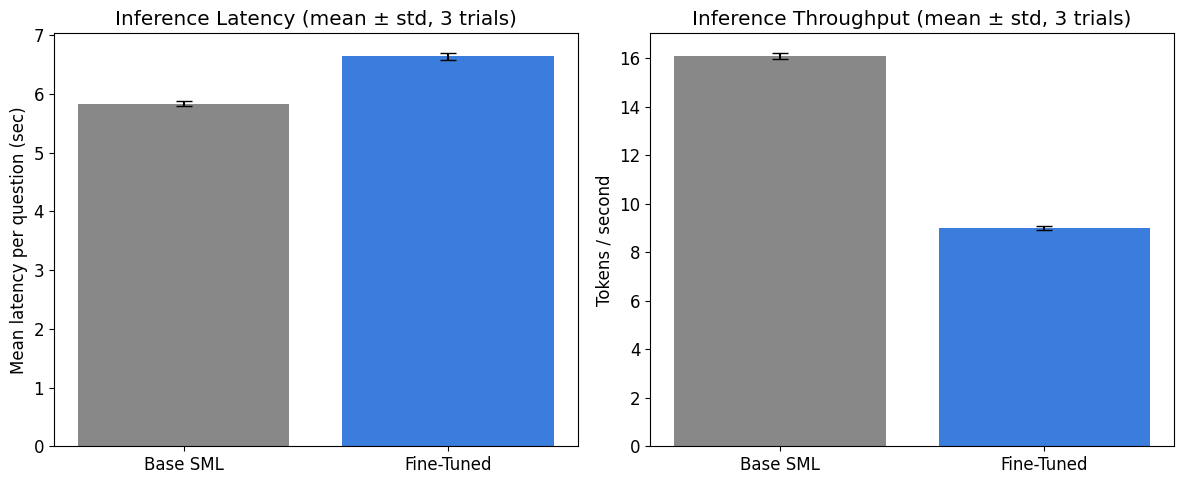

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

systems = ["Base SML", "Fine-Tuned"]
latencies = [baseline_infer_stats["mean_latency_sec"], finetuned_infer_stats["mean_latency_sec"]]
latency_errs = [baseline_infer_stats["std_latency_sec"], finetuned_infer_stats["std_latency_sec"]]
axes[0].bar(systems, latencies, yerr=latency_errs, capsize=6, color=["#888888", "#3b7ddd"])
axes[0].set_ylabel("Mean latency per question (sec)")
axes[0].set_title(f"Inference Latency (mean ± std, {N_TRIALS} trials)")

throughputs = [baseline_infer_stats["mean_throughput_tokens_per_sec"],
               finetuned_infer_stats["mean_throughput_tokens_per_sec"]]
throughput_errs = [baseline_infer_stats["std_throughput_tokens_per_sec"],
                    finetuned_infer_stats["std_throughput_tokens_per_sec"]]
axes[1].bar(systems, throughputs, yerr=throughput_errs, capsize=6, color=["#888888", "#3b7ddd"])
axes[1].set_ylabel("Tokens / second")
axes[1].set_title(f"Inference Throughput (mean ± std, {N_TRIALS} trials)")

plt.tight_layout()
plt.savefig(project_path + "/plots/inference_efficiency.png")
plt.show()


## 12.5 Efficiency Summary and Discussion

All efficiency evidence consolidated and saved, followed by a short discussion of what it does
and does not show.


In [70]:
efficiency_summary = {
    "parameter_efficiency": parameter_efficiency_stats,
    "training_efficiency": training_efficiency_stats,
    "inference_efficiency": {
        "finetuned": finetuned_infer_stats,
        "base_sml_baseline": baseline_infer_stats,
    },
    "answer_quality_reference": {
        "baseline": baseline_results,
        "finetuned": finetuned_results,
    },
}

with open(project_path + "/results/efficiency_summary.json", "w") as f:
    json.dump(efficiency_summary, f, indent=2, default=str)

print("Full efficiency summary saved to:", project_path + "/results/efficiency_summary.json")
print(json.dumps(efficiency_summary, indent=2, default=str))


Full efficiency summary saved to: /content/drive/MyDrive/Agriculture_QA/results/efficiency_summary.json
{
  "parameter_efficiency": {
    "total_base_parameters": 1104553984,
    "trainable_lora_parameters": 4505600,
    "pct_trainable": 0.40791125334440875,
    "adapter_size_on_disk_mb": 21.171616554260254,
    "full_finetune_reference_size_mb": 2106.76953125
  },
  "training_efficiency": {
    "training_wall_time_sec": 1736.4834191799164,
    "training_wall_time_min": 28.941390319665274,
    "peak_gpu_memory_gb": 2.713902473449707,
    "num_train_epochs": 3,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 8,
    "effective_batch_size": 16,
    "train_runtime_sec_trainer_reported": 1735.6774,
    "train_samples_per_second": 2.598
  },
  "inference_efficiency": {
    "finetuned": {
      "num_queries_per_trial": 10,
      "num_trials": 3,
      "mean_latency_sec": 6.63883900642395,
      "std_latency_sec": 0.05914375604592618,
      "mean_throughput_tokens_per_

**Discussion.** The LoRA adapter adds a small number of extra matrix multiplications at
inference time, so some latency/throughput difference between the base and fine-tuned arms in
Section 12.3 is expected and is not itself evidence of inefficiency — what matters is whether
that difference is small relative to the quality gain shown in Part 11. The main efficiency
claim this project supports is not "inference is faster" but "domain adaptation was achieved
by training under 1% of the model's parameters (Section 12.1), in the time and peak memory
reported in Section 12.2, on a single free-tier GPU" — that is the comparison against the
realistic alternative (full fine-tuning, or a larger model that would not fit on this
hardware at all), not against the base model's own inference speed. Both comparisons are now
reported explicitly so the report can state which claim is being made.


---
## End of Notebook A — Training, Evaluation, and Efficiency Benchmarking

At this point the fine-tuned LoRA adapter and tokenizer are saved to Google Drive at:

/content/drive/MyDrive/Agriculture_QA/models/tinyllama_qlora_final

**I have also saved the model in the GitHub repo and added the link in documentation**

**This notebook's Python session (its runtime/kernel) can now be fully disconnected or
restarted.** The next notebook — **Notebook B: Reload & Question Answering** — is a
completely separate file with no training code in it at all. It starts a brand-new session,
mounts the same Drive, loads the model **only from the files saved above**, and answers
questions — demonstrating that the trained model persists across sessions and needs no
retraining to be used.
